# EdgeNetV4 — Cross-Dataset Validation

Evaluates the trained EdgeNetV4 checkpoint (**epoch 124, composite F1 = 0.9662**) on each source dataset independently:
- MVTec Anomaly Detection (typed defect labels)
- Casting Product Dataset (binary only)
- Magnetic Tile Dataset (path-derived defect types)

Uses the existing `test` split from the CSV if available; otherwise carves a **stratified 10 % hold-out** per dataset.

In [1]:
# ======================================================================
# CELL 1 — PATHS & GLOBAL CONSTANTS
# Edit only this cell if your file locations differ.
# ======================================================================

import os

# ── File paths ─────────────────────────────────────────────────────────
V4_CKPT      = '/home/sufi/training_results/models/V4/EdgeNet_V4_best.pth'
METADATA_CSV = '/home/sufi/merged_dataset_metadata_augmented.csv'
OUT_DIR      = '/home/sufi/training_results/figures/cross_dataset_eval'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Semantic defect groups (8 classes, index 0-7) ──────────────────────
SEMANTIC_GROUPS = [
    'contamination',   # 0
    'cut',             # 1
    'deformation',     # 2
    'fracture',        # 3
    'hole_void',       # 4
    'minor_defect',    # 5
    'scratch',         # 6
    'surface_quality', # 7
]
NUM_DEFECT_TYPES  = len(SEMANTIC_GROUPS)   # 8
NUM_PRODUCT_TYPES = 17

DEFECT_TYPE_TO_IDX = {name: idx for idx, name in enumerate(SEMANTIC_GROUPS)}
IDX_TO_DEFECT_TYPE = {idx: name for idx, name in enumerate(SEMANTIC_GROUPS)}

# ── Raw dataset label  →  semantic group ──────────────────────────────
DEFECT_GROUP_MAP = {
    # fracture family
    'crack':               'fracture',
    'fracture':            'fracture',
    'faulty_imprint':      'fracture',
    # hole / void family
    'hole':                'hole_void',
    'void':                'hole_void',
    'pit':                 'hole_void',
    'blowhole':            'hole_void',
    # scratch family
    'scratch':             'scratch',
    'score':               'scratch',
    # surface quality family
    'stain':               'surface_quality',
    'color':               'surface_quality',
    'rough':               'surface_quality',
    'uneven':              'surface_quality',
    'inclusion':           'surface_quality',
    'discolor':            'surface_quality',
    'pilling':             'surface_quality',
    # deformation family
    'bent':                'deformation',
    'bent_lead':           'deformation',
    'squeeze':             'deformation',
    'deformation':         'deformation',
    # contamination family
    'contamination':       'contamination',
    'glue':                'contamination',
    'oil':                 'contamination',
    'glue_strip':          'contamination',
    'liquid':              'contamination',
    'metal_contamination': 'contamination',
    # minor defect family
    'missing':             'minor_defect',
    'misplaced':           'minor_defect',
    'flip':                'minor_defect',
    'missing_hole':        'minor_defect',
    'thread':              'minor_defect',
    'cable_swap':          'minor_defect',
    'combined':            'minor_defect',
    # cut
    'cut':                 'cut',
    # passthrough (already in semantic form)
    'hole_void':           'hole_void',
    'surface_quality':     'surface_quality',
    'minor_defect':        'minor_defect',
}

# ── Magnetic tile path  →  defect class index ─────────────────────────
def magnetic_path_to_class(path):
    """Derive semantic defect class from magnetic tile image path."""
    p = path.lower()
    if 'mt_blowhole' in p: return 4   # hole_void
    if 'mt_break'    in p: return 3   # fracture
    if 'mt_crack'    in p: return 3   # fracture
    if 'mt_fray'     in p: return 7   # surface_quality
    if 'mt_uneven'   in p: return 7   # surface_quality
    return -1                          # MT_Free = normal, skip

print('=' * 55)
print('CELL 1 COMPLETE')
print(f'  OUT_DIR          : {OUT_DIR}')
print(f'  Defect classes   : {NUM_DEFECT_TYPES}')
print(f'  Product classes  : {NUM_PRODUCT_TYPES}')
print(f'  Classes          : {SEMANTIC_GROUPS}')
print('=' * 55)

CELL 1 COMPLETE
  OUT_DIR          : /home/sufi/training_results/figures/cross_dataset_eval
  Defect classes   : 8
  Product classes  : 17
  Classes          : ['contamination', 'cut', 'deformation', 'fracture', 'hole_void', 'minor_defect', 'scratch', 'surface_quality']


In [2]:
# ======================================================================
# CELL 2 — IMPORTS & DEVICE
# ======================================================================

import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_auc_score,
    precision_recall_fscore_support,
    roc_curve,
    auc,
    classification_report,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 55)
print('CELL 2 COMPLETE — All imports OK')
print(f'  Device : {device}')
print('=' * 55)

/home/sufi/miniconda3/envs/organized/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CELL 2 COMPLETE — All imports OK
  Device : cuda


In [3]:
# ======================================================================
# CELL 3 — EdgeNetV4 MODEL DEFINITION
# Exact same architecture used during training.
#
# Backbone  : EfficientNet-B2 (timm, features_only)
# Features  : f2=48ch@stride8 | f3=120ch@stride16 | f4=352ch@stride32
# Attention : CoordAttention on f3 and f4
# Neck      : GAP(f4) → Linear(352→512) → BN → SiLU → Dropout(0.35)
# Outputs   : binary_logit [B,1]
#             defect_logit [B,8]   (multi-scale: f2+f3+f4)
#             product_logit [B,17]
# ======================================================================

class CoordAttention(nn.Module):
    """
    Coordinate Attention (Hou et al., 2021).
    conv_h / conv_w initialised weight=0, bias=+10 → sigmoid(10)≈1 → identity.
    _id_init() is re-applied after _init_heads() so kaiming cannot overwrite it.
    """
    def __init__(self, ch, reduction=32):
        super().__init__()
        mid = max(8, ch // reduction)
        self.conv1  = nn.Conv2d(ch, mid, 1, bias=False)
        self.bn1    = nn.BatchNorm2d(mid)
        self.act    = nn.ReLU(inplace=True)
        self.conv_h = nn.Conv2d(mid, ch, 1, bias=True)
        self.conv_w = nn.Conv2d(mid, ch, 1, bias=True)
        self._id_init()

    def _id_init(self):
        nn.init.zeros_(self.conv_h.weight)
        nn.init.constant_(self.conv_h.bias, 10.0)
        nn.init.zeros_(self.conv_w.weight)
        nn.init.constant_(self.conv_w.bias, 10.0)

    def forward(self, x):
        B, C, H, W = x.shape
        x_h = x.mean(dim=3, keepdim=True)                       # [B,C,H,1]
        x_w = x.mean(dim=2, keepdim=True).permute(0, 1, 3, 2)  # [B,C,W,1]
        y   = self.act(self.bn1(self.conv1(torch.cat([x_h, x_w], dim=2))))
        x_h, x_w = torch.split(y, [H, W], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)
        return x * torch.sigmoid(self.conv_h(x_h)) \
                 * torch.sigmoid(self.conv_w(x_w))


class EdgeNetV4(nn.Module):
    def __init__(self, num_defect_classes=8, num_product_classes=17):
        super().__init__()

        # EfficientNet-B2 backbone — pretrained=False because we load from .pth
        self.backbone = timm.create_model(
            'efficientnet_b2',
            pretrained=False,
            features_only=True,
            out_indices=(2, 3, 4),
        )
        chs = self.backbone.feature_info.channels()  # [48, 120, 352]
        c2, c3, c4 = chs[0], chs[1], chs[2]

        # Spatial attention on mid and deep feature maps
        self.ca_mid  = CoordAttention(c3)  # 120-ch
        self.ca_deep = CoordAttention(c4)  # 352-ch

        # Shared semantic neck (deepest feature only)
        self.neck = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(c4, 512, bias=False),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(0.35),
        )

        # Binary head  → [B, 1]
        self.binary_head = nn.Linear(512, 1)

        # Product head → [B, 17]
        self.product_head = nn.Sequential(
            nn.Linear(512, 256, bias=False),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_product_classes),
        )

        # Multi-scale defect head — concat GAP(f2, f3, f4) = 48+120+352 = 520d
        defect_in = c2 + c3 + c4  # 520
        self.defect_gap  = nn.AdaptiveAvgPool2d(1)
        self.defect_head = nn.Sequential(
            nn.Linear(defect_in, 384, bias=False),
            nn.BatchNorm1d(384),
            nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(384, 192, bias=False),
            nn.BatchNorm1d(192),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(192, num_defect_classes),
        )

        self._init_heads()
        # Re-apply identity init AFTER _init_heads to prevent kaiming overwrite
        self.ca_mid._id_init()
        self.ca_deep._id_init()

    def _init_heads(self):
        for module in [self.neck, self.binary_head,
                       self.product_head, self.defect_head]:
            for layer in module.modules():
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    if layer.bias is not None:
                        nn.init.zeros_(layer.bias)
                elif isinstance(layer, (nn.BatchNorm1d, nn.BatchNorm2d)):
                    nn.init.ones_(layer.weight)
                    nn.init.zeros_(layer.bias)

    def forward(self, x):
        f2, f3, f4 = self.backbone(x)          # 48@s8, 120@s16, 352@s32
        f3 = self.ca_mid(f3)
        f4 = self.ca_deep(f4)
        shared   = self.neck(f4)               # [B, 512]
        bin_out  = self.binary_head(shared)    # [B, 1]
        prod_out = self.product_head(shared)   # [B, 17]
        d2 = self.defect_gap(f2).flatten(1)    # [B, 48]
        d3 = self.defect_gap(f3).flatten(1)    # [B, 120]
        d4 = self.defect_gap(f4).flatten(1)    # [B, 352]
        def_out = self.defect_head(torch.cat([d2, d3, d4], dim=1))  # [B, 8]
        return bin_out, def_out, prod_out

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad) / 1e6


# Build model (weights loaded in Cell 4)
model = EdgeNetV4(
    num_defect_classes  = NUM_DEFECT_TYPES,
    num_product_classes = NUM_PRODUCT_TYPES,
).to(device)

# Quick shape check
model.eval()
with torch.no_grad():
    _dummy = torch.randn(2, 3, 224, 224).to(device)
    _b, _d, _p = model(_dummy)
    assert _b.shape == (2, 1),                 f'binary wrong  : {_b.shape}'
    assert _d.shape == (2, NUM_DEFECT_TYPES),  f'defect wrong  : {_d.shape}'
    assert _p.shape == (2, NUM_PRODUCT_TYPES), f'product wrong : {_p.shape}'
    del _dummy, _b, _d, _p

print('=' * 55)
print('CELL 3 COMPLETE — EdgeNetV4 built')
print(f'  Backbone   : EfficientNet-B2 (timm, features_only)')
print(f'  Features   : 48ch@s8 + 120ch@s16 + 352ch@s32')
print(f'  Defect in  : 520 → 384 → 192 → {NUM_DEFECT_TYPES}')
print(f'  Params     : {model.count_params():.2f}M')
print(f'  Shape test : binary(2,1) defect(2,8) product(2,17) ✅')
print('=' * 55)

CELL 3 COMPLETE — EdgeNetV4 built
  Backbone   : EfficientNet-B2 (timm, features_only)
  Features   : 48ch@s8 + 120ch@s16 + 352ch@s32
  Defect in  : 520 → 384 → 192 → 8
  Params     : 7.81M
  Shape test : binary(2,1) defect(2,8) product(2,17) ✅


In [4]:
# ======================================================================
# CELL 4 — LOAD CHECKPOINT & CONFIRM SCORE = 0.9662
# ======================================================================

ckpt = torch.load(V4_CKPT, map_location=device, weights_only=False)

# The checkpoint stores 'model_state_dict'; fall back to root dict if not found
state_dict = ckpt.get('model_state_dict', ckpt)
missing, unexpected = model.load_state_dict(state_dict, strict=True)

saved_epoch = ckpt.get('epoch', 'N/A')
saved_score = ckpt.get('score', float('nan'))

print('=' * 55)
print('CELL 4 — CHECKPOINT VERIFICATION')
print('=' * 55)
print(f'  Path         : {V4_CKPT}')
print(f'  Epoch        : {saved_epoch}')
print(f'  Saved score  : {saved_score:.4f}')

if abs(saved_score - 0.9662) < 0.001:
    print('  Score check  : ✅  CONFIRMED — matches 0.9662')
else:
    print(f'  Score check  : ⚠️  got {saved_score:.4f}, expected 0.9662')

if missing:
    print(f'  Missing keys : {missing[:5]}')
if unexpected:
    print(f'  Extra keys   : {unexpected[:5]}')
if not missing and not unexpected:
    print('  Weight load  : ✅  strict=True, 0 missing, 0 unexpected')

print('=' * 55)

model.eval()
print('Model set to eval() mode — ready for inference.')

CELL 4 — CHECKPOINT VERIFICATION
  Path         : /home/sufi/training_results/models/V4/EdgeNet_V4_best.pth
  Epoch        : 124
  Saved score  : 0.9662
  Score check  : ✅  CONFIRMED — matches 0.9662
  Weight load  : ✅  strict=True, 0 missing, 0 unexpected
Model set to eval() mode — ready for inference.


In [5]:
# ======================================================================
# CELL 5 — LOAD METADATA CSV & COMPUTE ALL LABELS
# Computes: binary_label, defect_type_label, product_type_label
# ======================================================================

df_all = pd.read_csv(METADATA_CSV)

# ── Safe column renames (handles older CSV versions) ──────────────────
if 'path'     in df_all.columns: df_all.rename(columns={'path': 'image_path'},     inplace=True)
if 'category' in df_all.columns: df_all.rename(columns={'category': 'product_type'}, inplace=True)

print(f'Rows loaded : {len(df_all):,}')
print(f'Columns     : {list(df_all.columns)}')

# ── Binary label ───────────────────────────────────────────────────────
# 0 = normal/good, 1 = defective
_NORMAL_STRINGS = {'0', 'good', 'normal', 'ok', 'casting_ok'}

def compute_binary(v):
    if pd.isna(v):
        return 0
    return 0 if str(v).strip().lower() in _NORMAL_STRINGS else 1

df_all['binary_label'] = df_all['label'].apply(compute_binary)

# ── Defect-type label (MVTec has named defect types) ───────────────────
# Maps raw defect names → integer index 0-7.
# Returns -1 for normal samples or unmapped types.
def remap_defect(raw):
    if pd.isna(raw):
        return -1
    s = str(raw).strip().lower()
    if s in ('good', 'normal', 'casting_ok', ''):
        return -1
    # Direct lookup
    sem = DEFECT_GROUP_MAP.get(s)
    # Already a semantic group name?
    if sem is None and s in SEMANTIC_GROUPS:
        sem = s
    # Partial match fallback
    if sem is None:
        for key, val in DEFECT_GROUP_MAP.items():
            if key in s:
                sem = val
                break
    return -1 if sem is None else DEFECT_TYPE_TO_IDX.get(sem, -1)

df_all['defect_type_label'] = df_all['defect_type'].apply(remap_defect)
# Normal samples always get -1 regardless of defect_type column
df_all.loc[df_all['binary_label'] == 0, 'defect_type_label'] = -1

# ── Product label (integer index 0-16) ────────────────────────────────
all_products = sorted(df_all['product_type'].dropna().unique().tolist())
PRODUCT_TYPE_TO_IDX = {p: i for i, p in enumerate(all_products)}
IDX_TO_PRODUCT_TYPE = {i: p for i, p in enumerate(all_products)}

# Explicit loop avoids pandas.Series.map + numpy.matrix edge-case bug
_prod_labels = []
for v in df_all['product_type']:
    if pd.isna(v):
        _prod_labels.append(0)
    else:
        _prod_labels.append(PRODUCT_TYPE_TO_IDX.get(str(v), 0))
df_all['product_type_label'] = _prod_labels

# ── Summary per dataset ───────────────────────────────────────────────
print()
print(f'{"Dataset":<15} {"Rows":>7}  {"Normal":>7}  {"Defective":>10}  {"Typed":>7}  {"Has test split"}')
print('-' * 65)
for ds_name, grp in df_all.groupby('dataset'):
    n_total   = len(grp)
    n_normal  = int((grp['binary_label'] == 0).sum())
    n_def     = int((grp['binary_label'] == 1).sum())
    n_typed   = int((grp['defect_type_label'] >= 0).sum())
    has_test  = ('split' in grp.columns) and ('test' in grp['split'].values)
    print(f'{ds_name:<15} {n_total:>7,}  {n_normal:>7,}  {n_def:>10,}  {n_typed:>7,}  {has_test}')

print()
print(f'Total binary_label=1 : {(df_all["binary_label"]==1).sum():,}')
print(f'Total binary_label=0 : {(df_all["binary_label"]==0).sum():,}')
print(f'Products found       : {all_products}')
print()
print('=' * 55)
print('CELL 5 COMPLETE — Labels computed')
print('=' * 55)

Rows loaded : 21,344
Columns     : ['image_path', 'dataset', 'product_type', 'defect_type', 'label', 'split', 'defect_group', 'defect_type_label', 'binary_label']

Dataset            Rows   Normal   Defective    Typed  Has test split
-----------------------------------------------------------------
casting           8,648    3,656       4,992        0  True
magnetic          2,997    1,904       1,093      859  True
mvtec             7,231    4,096       3,135    2,839  True
synthetic         2,468        0       2,468    2,468  False

Total binary_label=1 : 11,688
Total binary_label=0 : 9,656
Products found       : ['bottle', 'cable', 'capsule', 'carpet', 'casting_product', 'grid', 'hazelnut', 'leather', 'magnetic_tile', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']

CELL 5 COMPLETE — Labels computed


In [6]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — BUILD PER-DATASET TEST SPLITS                         ║
# ║  Rule: use 'test' split if it exists, else 10% stratified hold  ║
# ╚══════════════════════════════════════════════════════════════════╝

HOLDOUT_FRAC = 0.10   # 10 % fallback
RANDOM_SEED  = 42

dataset_test_dfs   = {}   # {dataset_name: DataFrame}
dataset_split_mode = {}   # {dataset_name: 'csv_test' | '10pct_holdout'}

for ds_name, grp in df_all.groupby('dataset'):
    grp = grp.reset_index(drop=True)

    if 'split' in grp.columns and 'test' in grp['split'].values:
        # ── Use existing test split ────────────────────────────────
        test_df = grp[grp['split'] == 'test'].reset_index(drop=True)
        mode    = 'csv_test'
    else:
        # ── 10 % stratified on binary_label ───────────────────────
        _, test_df = train_test_split(
            grp,
            test_size    = HOLDOUT_FRAC,
            stratify     = grp['binary_label'],
            random_state = RANDOM_SEED,
        )
        test_df = test_df.reset_index(drop=True)
        mode    = '10pct_holdout'

    dataset_test_dfs[ds_name]   = test_df
    dataset_split_mode[ds_name] = mode

print('Test-split summary:')
print('-' * 70)
for ds_name, df_t in dataset_test_dfs.items():
    n_norm = (df_t['binary_label'] == 0).sum()
    n_def  = (df_t['binary_label'] == 1).sum()
    n_typ  = (df_t['defect_type_label'] >= 0).sum()
    mode   = dataset_split_mode[ds_name]
    print(f'  {ds_name:<15} mode={mode:<15}  '
          f'total={len(df_t):>5,}  normal={n_norm:>4}  defective={n_def:>4}  typed={n_typ:>4}')

print('✅ CELL 6 COMPLETE')

Test-split summary:
----------------------------------------------------------------------
  casting         mode=csv_test         total=  850  normal= 347  defective= 503  typed=   0
  magnetic        mode=csv_test         total=  262  normal= 190  defective=  72  typed=  51
  mvtec           mode=csv_test         total=  556  normal= 428  defective= 128  typed=  97
  synthetic       mode=10pct_holdout    total=  247  normal=   0  defective= 247  typed= 247
✅ CELL 6 COMPLETE


In [7]:
INFERENCE_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

BATCH_SIZE  = 32
NUM_WORKERS = 4


class InferenceDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['image_path']).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224), color=(128, 128, 128))
        img = self.transform(img)
        return (
            img,
            int(row['binary_label']),
            int(row['defect_type_label']),
            int(row.get('product_type_label', 0)),
            str(row['image_path']),
        )


def make_loader(df):
    ds = InferenceDataset(df, INFERENCE_TRANSFORM)
    return DataLoader(ds, batch_size=BATCH_SIZE,
                      shuffle=False, num_workers=NUM_WORKERS,
                      pin_memory=True)


dataset_loaders = {ds: make_loader(df) for ds, df in dataset_test_dfs.items()}

for ds, loader in dataset_loaders.items():
    print(f'  {ds:<15} {len(loader)} batches  ({len(loader.dataset)} samples)')

print('✅ CELL 7 COMPLETE')

  casting         27 batches  (850 samples)
  magnetic        9 batches  (262 samples)
  mvtec           18 batches  (556 samples)
  synthetic       8 batches  (247 samples)
✅ CELL 7 COMPLETE


In [8]:
def run_inference(model, loader, ds_name, df_ref, magnetic_fn=None):
    model.eval().to(device)
    bt, dt, bs, dp, dpr, paths = [], [], [], [], [], []

    with torch.no_grad():
        for batch in loader:
            img          = batch[0].to(device)
            binary_true  = np.array(batch[1])
            defect_true  = np.array(batch[2])
            batch_paths  = list(batch[4])

            if ds_name == 'magnetic' and magnetic_fn is not None:
                for i, (bl, dl, p) in enumerate(
                        zip(binary_true, defect_true, batch_paths)):
                    if bl == 1 and dl < 0:
                        defect_true[i] = magnetic_fn(p)

            out           = model(img)
            binary_logits = out[0]
            defect_logits = out[1]

            bin_scores  = torch.sigmoid(binary_logits.squeeze(-1)).cpu().numpy()
            def_probs   = torch.softmax(defect_logits, dim=1).cpu().numpy()
            def_preds   = def_probs.argmax(axis=1)

            bt.extend(binary_true.tolist())
            dt.extend(defect_true.tolist())
            bs.extend(bin_scores.tolist())
            dp.extend(def_preds.tolist())
            dpr.append(def_probs)
            paths.extend(batch_paths)

    result = {
        'binary_true'  : np.array(bt),
        'defect_true'  : np.array(dt),
        'binary_scores': np.array(bs),
        'defect_preds' : np.array(dp),
        'defect_probs' : np.vstack(dpr),
        'image_paths'  : paths,
    }

    n_def   = int((result['binary_true'] == 1).sum())
    n_typed = int(((result['binary_true'] == 1) &
                   (result['defect_true']  >= 0)).sum())
    print(f'  [{ds_name}]  total={len(bt):,}  '
          f'defective={n_def:,}  typed_defect={n_typed:,}')
    return result


print('Running inference...')
all_results = {}
for ds_name, loader in dataset_loaders.items():
    df_ref = dataset_test_dfs[ds_name]
    all_results[ds_name] = run_inference(
        model, loader, ds_name, df_ref,
        magnetic_fn=magnetic_path_to_class
    )

gc.collect()
torch.cuda.empty_cache()
print('\n✅ CELL 8 COMPLETE — inference done for all datasets')

Running inference...
  [casting]  total=850  defective=503  typed_defect=0
  [magnetic]  total=262  defective=72  typed_defect=72
  [mvtec]  total=556  defective=128  typed_defect=97
  [synthetic]  total=247  defective=247  typed_defect=247

✅ CELL 8 COMPLETE — inference done for all datasets


In [10]:
CM_CMAP = LinearSegmentedColormap.from_list(
    'edgenet_blues', ['#f0f7ff', '#c7dff7', '#2563eb', '#1e3a8a'], N=256)

def f1_color(v):
    if v >= 0.96: return '#16a34a'
    if v >= 0.90: return '#ea580c'
    return '#dc2626'


def plot_confusion_matrix(
        y_true, y_pred, title, save_name,
        class_names=SEMANTIC_GROUPS, epoch=124):
    if len(y_true) == 0:
        print(f'  SKIP "{title}" — no samples'); return None

    N       = len(class_names)
    labels  = list(range(N))
    cm_raw  = confusion_matrix(y_true, y_pred, labels=labels)
    row_tot = cm_raw.sum(axis=1, keepdims=True).clip(min=1)
    cm_norm = cm_raw / row_tot

    macro_f1 = f1_score(y_true, y_pred, average='macro',
                        labels=labels, zero_division=0)
    _, _, f1_per, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0)

    fig = plt.figure(figsize=(14, 9.5), dpi=150, facecolor='white')
    ax      = fig.add_axes([0.09, 0.14, 0.62, 0.72])
    ax_bar  = fig.add_axes([0.75, 0.14, 0.18, 0.72])

    im = ax.imshow(cm_norm, cmap=CM_CMAP, vmin=0, vmax=1, aspect='auto')
    for k in range(N + 1):
        ax.axhline(k - 0.5, color='#cbd5e1', lw=0.6, zorder=3)
        ax.axvline(k - 0.5, color='#cbd5e1', lw=0.6, zorder=3)

    for i in range(N):
        for j in range(N):
            cnt = cm_raw[i, j]
            if cnt == 0: continue
            v      = cm_norm[i, j]
            fc     = 'white' if v > 0.50 else '#1e293b'
            bold   = 'bold'  if i == j   else 'normal'
            fs_cnt = 11 if i == j else 9
            txt    = f'{cnt}\n({v:.0%})' if i == j else str(cnt)
            ax.text(j, i, txt, ha='center', va='center',
                    fontsize=fs_cnt, fontweight=bold,
                    color=fc, linespacing=1.35, zorder=4)

    y_labels = [f'{c}  (n={int(support[i])})'
                for i, c in enumerate(class_names)]
    ax.set_yticks(range(N)); ax.set_yticklabels(y_labels, fontsize=9)
    ax.set_xticks(range(N))
    ax.set_xticklabels(class_names, rotation=38, ha='right',
                       fontsize=9, rotation_mode='anchor')
    ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=11, labelpad=8)
    ax.set_ylabel('True Label',      fontweight='bold', fontsize=11, labelpad=8)

    cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.015)
    cbar.set_label('Recall within class', fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    y_pos  = np.arange(N)
    colors = [f1_color(v) for v in f1_per]
    bars   = ax_bar.barh(y_pos, f1_per, color=colors, height=0.55, zorder=3)
    ax_bar.set_xlim(max(0.0, f1_per.min() - 0.05), 1.02)
    ax_bar.axvline(0.90, color='#94a3b8', lw=0.8, ls='--', zorder=2)
    ax_bar.axvline(0.96, color='#475569', lw=0.8, ls='--', zorder=2)
    for i, (v, bar) in enumerate(zip(f1_per, bars)):
        ax_bar.text(v + 0.003, i, f'{v:.3f}', va='center',
                    fontsize=8.5, color='#0f172a', fontweight='bold')
    ax_bar.set_yticks(y_pos); ax_bar.set_yticklabels([])
    ax_bar.set_xlabel('Per-class F1', fontweight='bold', fontsize=9, labelpad=6)
    ax_bar.set_title('Per-class\nF1', fontsize=9, fontweight='bold', pad=4)
    ax_bar.tick_params(axis='x', labelsize=8)
    ax_bar.grid(axis='x', alpha=0.3, zorder=1)
    ax_bar.set_facecolor('#f8fafc')
    for sp in ['top', 'right']: ax_bar.spines[sp].set_visible(False)

    patches = [
        mpatches.Patch(color='#16a34a', label='F1 ≥ 0.96'),
        mpatches.Patch(color='#ea580c', label='0.90 ≤ F1 < 0.96'),
        mpatches.Patch(color='#dc2626', label='F1 < 0.90'),
    ]
    fig.legend(handles=patches, loc='lower center', ncol=3,
               fontsize=8.5, frameon=False, bbox_to_anchor=(0.43, 0.01))

    fig.suptitle(
        f'{title}\nMacro F1 = {macro_f1:.4f}  |  n = {len(y_true)}  |  Epoch {epoch}',
        fontsize=12, fontweight='bold', y=0.98)

    path = os.path.join(OUT_DIR, save_name + '.png')
    plt.savefig(path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'  Saved → {path}')

    return {
        'macro_f1'    : macro_f1,
        'per_class_f1': f1_per,
        'support'     : support,
        'cm'          : cm_raw,
    }


def plot_roc_curve(binary_true, binary_scores,
                   title, save_name, color='#2563eb'):
    fpr, tpr, _ = roc_curve(binary_true, binary_scores)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(6, 5), dpi=150, facecolor='white')
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.02])
    ax.set_xlabel('False Positive Rate', fontweight='bold')
    ax.set_ylabel('True Positive Rate',  fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    path = os.path.join(OUT_DIR, save_name + '.png')
    plt.savefig(path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'  Saved → {path}')
    return roc_auc


print('✅ CELL 9 COMPLETE — plotting utilities loaded')

✅ CELL 9 COMPLETE — plotting utilities loaded


MVTec Anomaly Detection — Test Evaluation  [csv_test]

[Binary Head]
  Samples     : 556  (normal=428  defective=128)
  F1 (binary) : 0.9551
  F1 (macro)  : 0.9712
  AUC-ROC     : 0.9926

              precision    recall  f1-score   support

      normal       0.97      1.00      0.99       428
   defective       1.00      0.91      0.96       128

    accuracy                           0.98       556
   macro avg       0.99      0.96      0.97       556
weighted avg       0.98      0.98      0.98       556



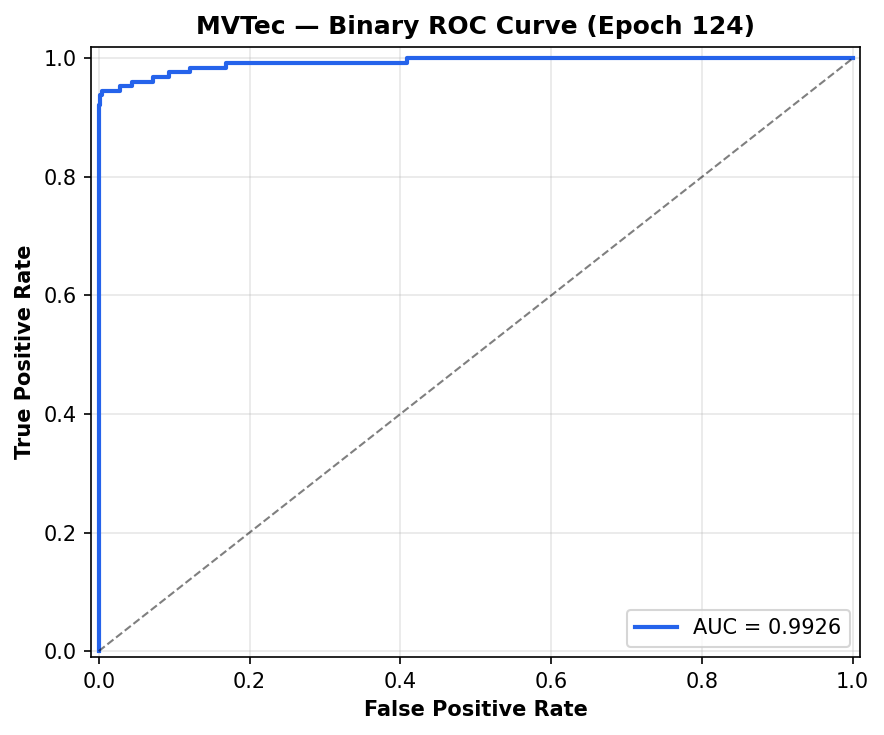

  Saved → /home/sufi/training_results/figures/cross_dataset_eval/mvtec_binary_roc.png

[Defect-Type Head]
  Typed defective samples : 97


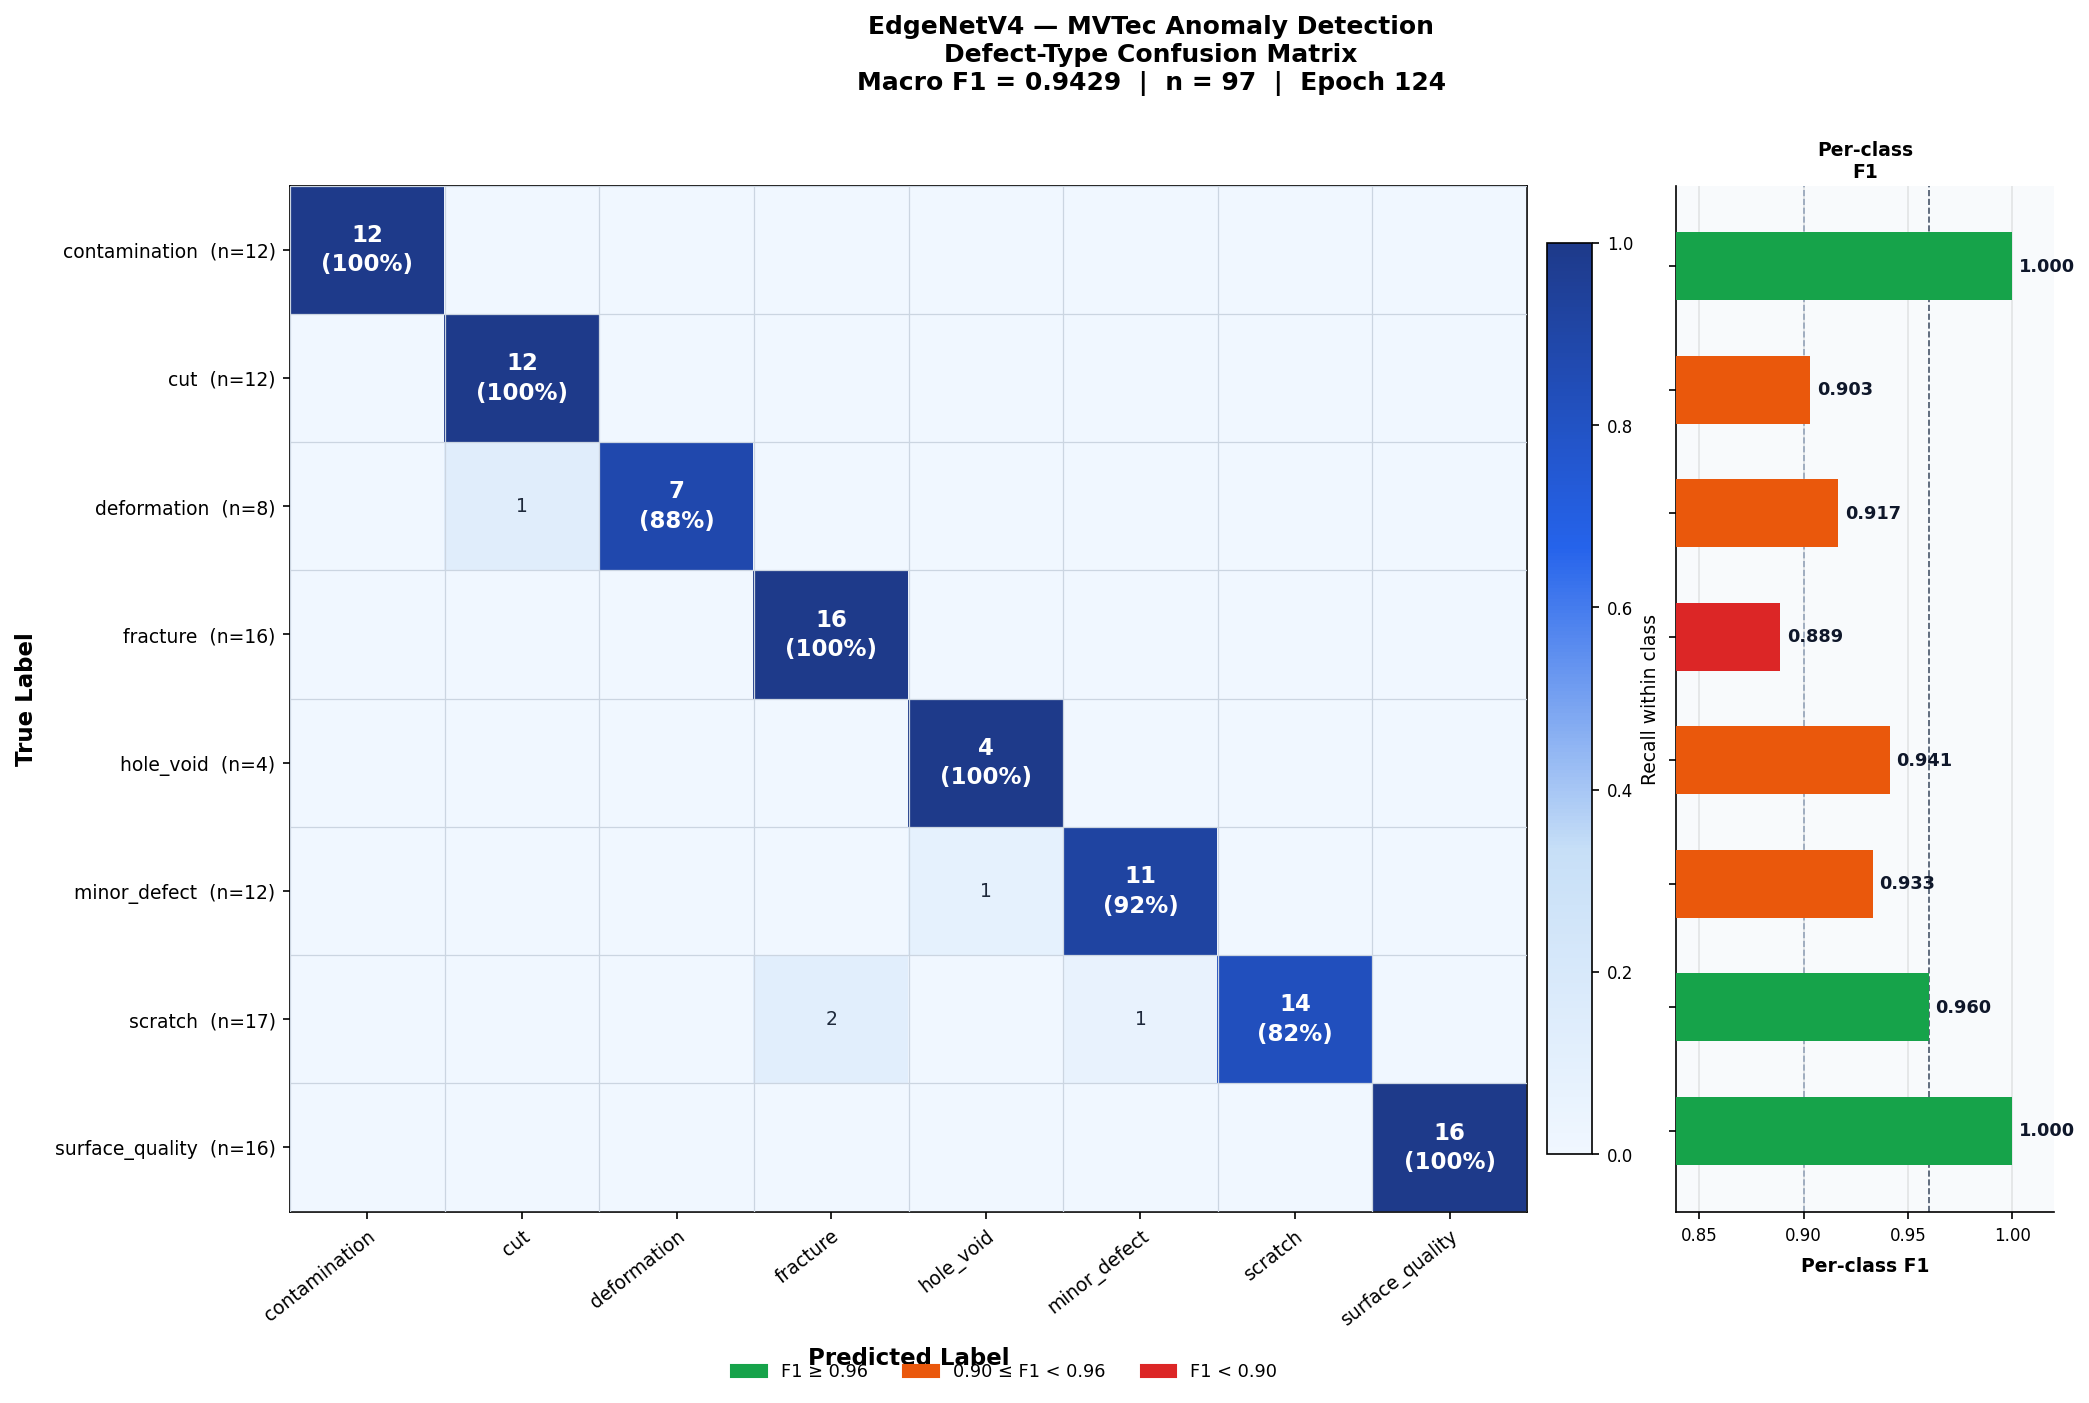

  Saved → /home/sufi/training_results/figures/cross_dataset_eval/mvtec_defect_cm.png
  Macro F1 : 0.9429


In [11]:
res = all_results['mvtec']
split_info = dataset_split_mode['mvtec']

print('=' * 65)
print(f'MVTec Anomaly Detection — Test Evaluation  [{split_info}]')
print('=' * 65)

bt  = res['binary_true']
bp  = (res['binary_scores'] >= 0.5).astype(int)
bs  = res['binary_scores']

bin_f1  = f1_score(bt, bp, average='binary', zero_division=0)
bin_mac = f1_score(bt, bp, average='macro',  zero_division=0)
try:
    bin_auc = roc_auc_score(bt, bs)
except Exception:
    bin_auc = float('nan')

print(f'\n[Binary Head]')
print(f'  Samples     : {len(bt):,}  (normal={int((bt==0).sum())}  defective={int((bt==1).sum())})')
print(f'  F1 (binary) : {bin_f1:.4f}')
print(f'  F1 (macro)  : {bin_mac:.4f}')
print(f'  AUC-ROC     : {bin_auc:.4f}')
print()
print(classification_report(bt, bp,
      target_names=['normal','defective'], zero_division=0))

mvtec_bin_auc = plot_roc_curve(
    bt, bs,
    title='MVTec — Binary ROC Curve (Epoch 124)',
    save_name='mvtec_binary_roc',
    color='#2563eb'
)

mask  = (res['binary_true'] == 1) & (res['defect_true'] >= 0)
y_t   = res['defect_true'][mask].astype(int)
y_p   = res['defect_preds'][mask].astype(int)

print(f'\n[Defect-Type Head]')
print(f'  Typed defective samples : {mask.sum()}')

if mask.sum() > 0:
    mvtec_cm_res = plot_confusion_matrix(
        y_t, y_p,
        title='EdgeNetV4 — MVTec Anomaly Detection\nDefect-Type Confusion Matrix',
        save_name='mvtec_defect_cm'
    )
    print(f'  Macro F1 : {mvtec_cm_res["macro_f1"]:.4f}')
else:
    mvtec_cm_res = None
    print('  No typed defects — skipping confusion matrix')

Casting Product Dataset — Test Evaluation  [csv_test]

[Binary Head]
  Samples     : 850  (normal=347  defective=503)
  F1 (binary) : 0.9990
  F1 (macro)  : 0.9988
  AUC-ROC     : 0.9999

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       347
   defective       1.00      1.00      1.00       503

    accuracy                           1.00       850
   macro avg       1.00      1.00      1.00       850
weighted avg       1.00      1.00      1.00       850



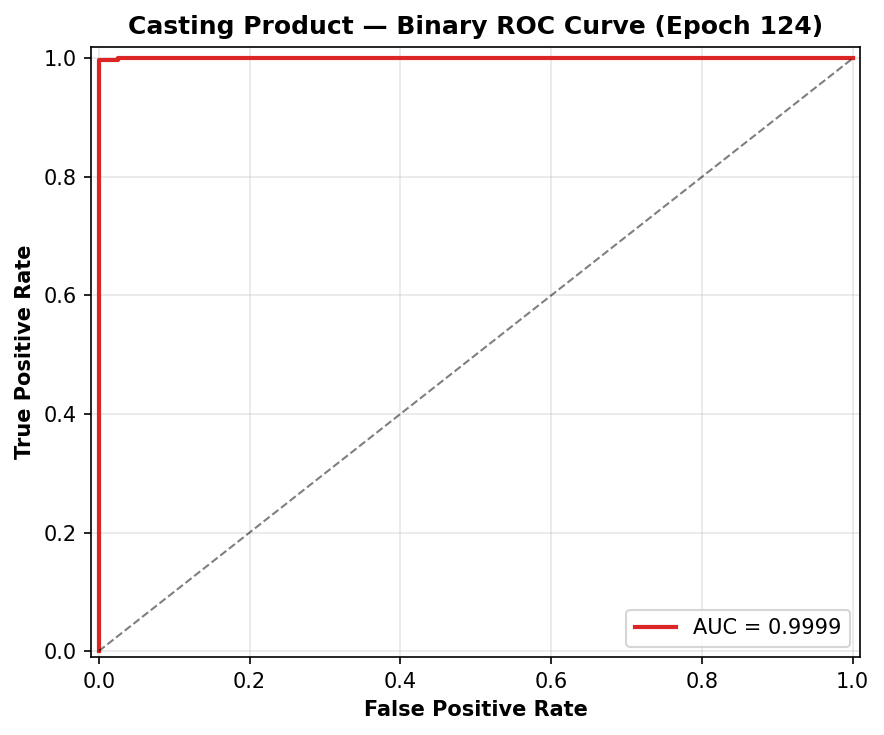

  Saved → /home/sufi/training_results/figures/cross_dataset_eval/casting_binary_roc.png


In [12]:
res = all_results['casting']
split_info = dataset_split_mode['casting']

print('=' * 65)
print(f'Casting Product Dataset — Test Evaluation  [{split_info}]')
print('=' * 65)

bt = res['binary_true']
bp = (res['binary_scores'] >= 0.5).astype(int)
bs = res['binary_scores']

bin_f1  = f1_score(bt, bp, average='binary', zero_division=0)
bin_mac = f1_score(bt, bp, average='macro',  zero_division=0)
try:
    bin_auc = roc_auc_score(bt, bs)
except Exception:
    bin_auc = float('nan')

print(f'\n[Binary Head]')
print(f'  Samples     : {len(bt):,}  (normal={int((bt==0).sum())}  defective={int((bt==1).sum())})')
print(f'  F1 (binary) : {bin_f1:.4f}')
print(f'  F1 (macro)  : {bin_mac:.4f}')
print(f'  AUC-ROC     : {bin_auc:.4f}')
print()
print(classification_report(bt, bp,
      target_names=['normal','defective'], zero_division=0))

casting_bin_auc = plot_roc_curve(
    bt, bs,
    title='Casting Product — Binary ROC Curve (Epoch 124)',
    save_name='casting_binary_roc',
    color='#dc2626'
)

casting_metrics = {
    'binary_f1' : bin_f1,
    'binary_mac': bin_mac,
    'auc'       : bin_auc,
}

Magnetic Tile Dataset — Test Evaluation  [csv_test]

[Binary Head]
  Samples     : 262  (normal=190  defective=72)
  F1 (binary) : 0.9722
  F1 (macro)  : 0.9808
  AUC-ROC     : 0.9823

              precision    recall  f1-score   support

      normal       0.99      0.99      0.99       190
   defective       0.97      0.97      0.97        72

    accuracy                           0.98       262
   macro avg       0.98      0.98      0.98       262
weighted avg       0.98      0.98      0.98       262



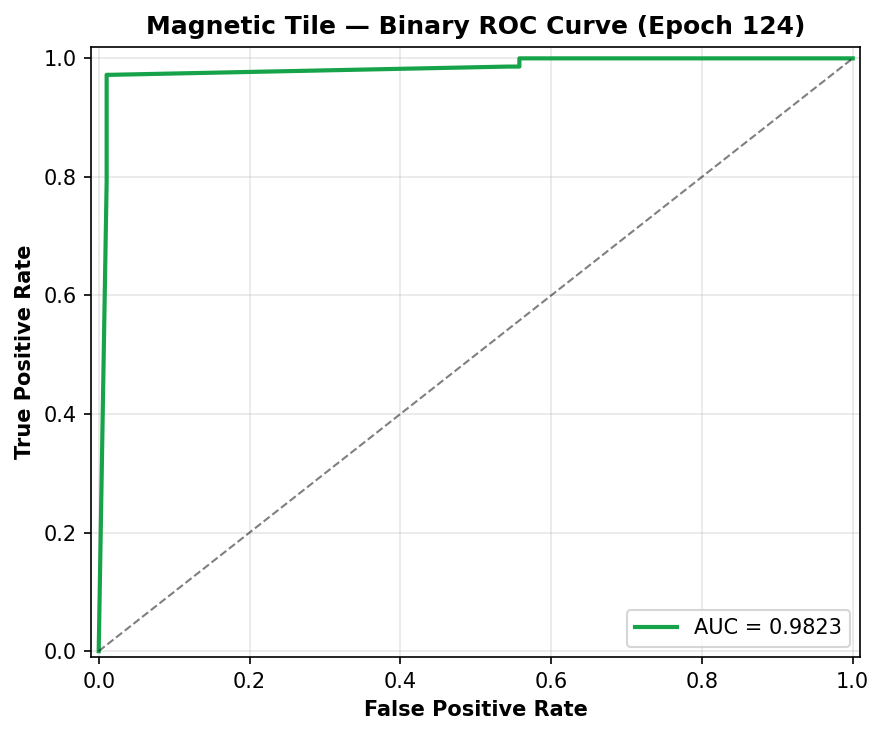

  Saved → /home/sufi/training_results/figures/cross_dataset_eval/magnetic_binary_roc.png

[Defect-Type Head — path-derived labels]
  Typed defective samples : 72


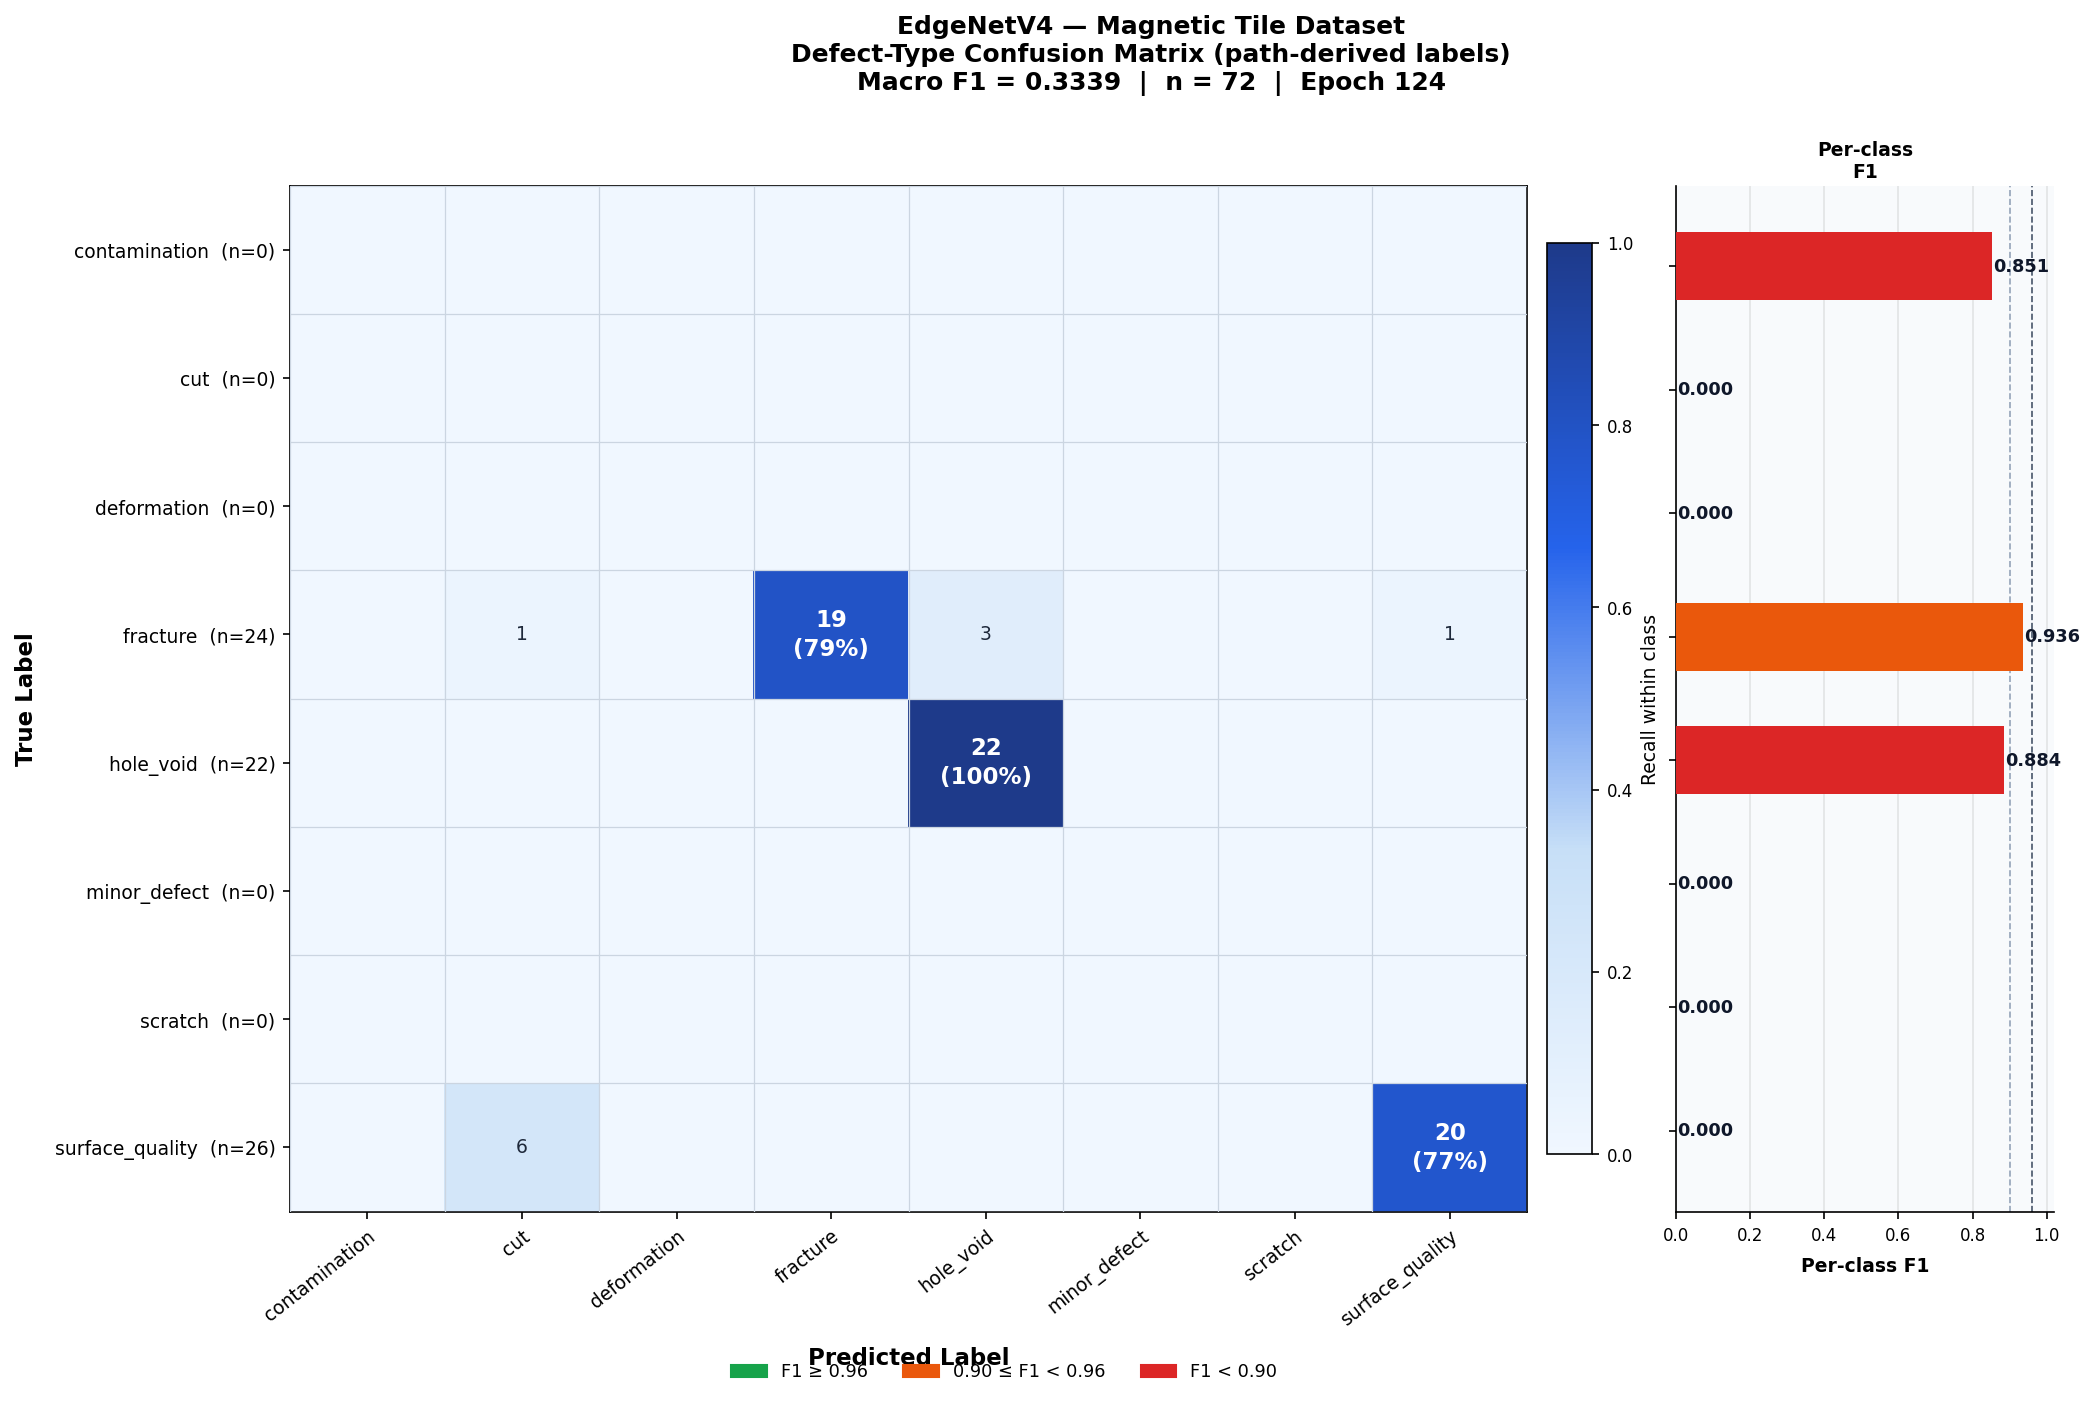

  Saved → /home/sufi/training_results/figures/cross_dataset_eval/magnetic_defect_cm.png
  Macro F1 : 0.3339


In [13]:
res = all_results['magnetic']
split_info = dataset_split_mode['magnetic']

print('=' * 65)
print(f'Magnetic Tile Dataset — Test Evaluation  [{split_info}]')
print('=' * 65)

bt = res['binary_true']
bp = (res['binary_scores'] >= 0.5).astype(int)
bs = res['binary_scores']

bin_f1  = f1_score(bt, bp, average='binary', zero_division=0)
bin_mac = f1_score(bt, bp, average='macro',  zero_division=0)
try:
    bin_auc = roc_auc_score(bt, bs)
except Exception:
    bin_auc = float('nan')

print(f'\n[Binary Head]')
print(f'  Samples     : {len(bt):,}  (normal={int((bt==0).sum())}  defective={int((bt==1).sum())})')
print(f'  F1 (binary) : {bin_f1:.4f}')
print(f'  F1 (macro)  : {bin_mac:.4f}')
print(f'  AUC-ROC     : {bin_auc:.4f}')
print()
print(classification_report(bt, bp,
      target_names=['normal','defective'], zero_division=0))

magnetic_bin_auc = plot_roc_curve(
    bt, bs,
    title='Magnetic Tile — Binary ROC Curve (Epoch 124)',
    save_name='magnetic_binary_roc',
    color='#16a34a'
)

mask  = (res['binary_true'] == 1) & (res['defect_true'] >= 0)
y_t   = res['defect_true'][mask].astype(int)
y_p   = res['defect_preds'][mask].astype(int)

print(f'\n[Defect-Type Head — path-derived labels]')
print(f'  Typed defective samples : {mask.sum()}')

if mask.sum() > 0:
    magnetic_cm_res = plot_confusion_matrix(
        y_t, y_p,
        title='EdgeNetV4 — Magnetic Tile Dataset\nDefect-Type Confusion Matrix (path-derived labels)',
        save_name='magnetic_defect_cm'
    )
    print(f'  Macro F1 : {magnetic_cm_res["macro_f1"]:.4f}')
else:
    magnetic_cm_res = None
    print('  No typed defects found — skipping confusion matrix')

magnetic_metrics = {
    'binary_f1' : bin_f1,
    'binary_mac': bin_mac,
    'auc'       : bin_auc,
}

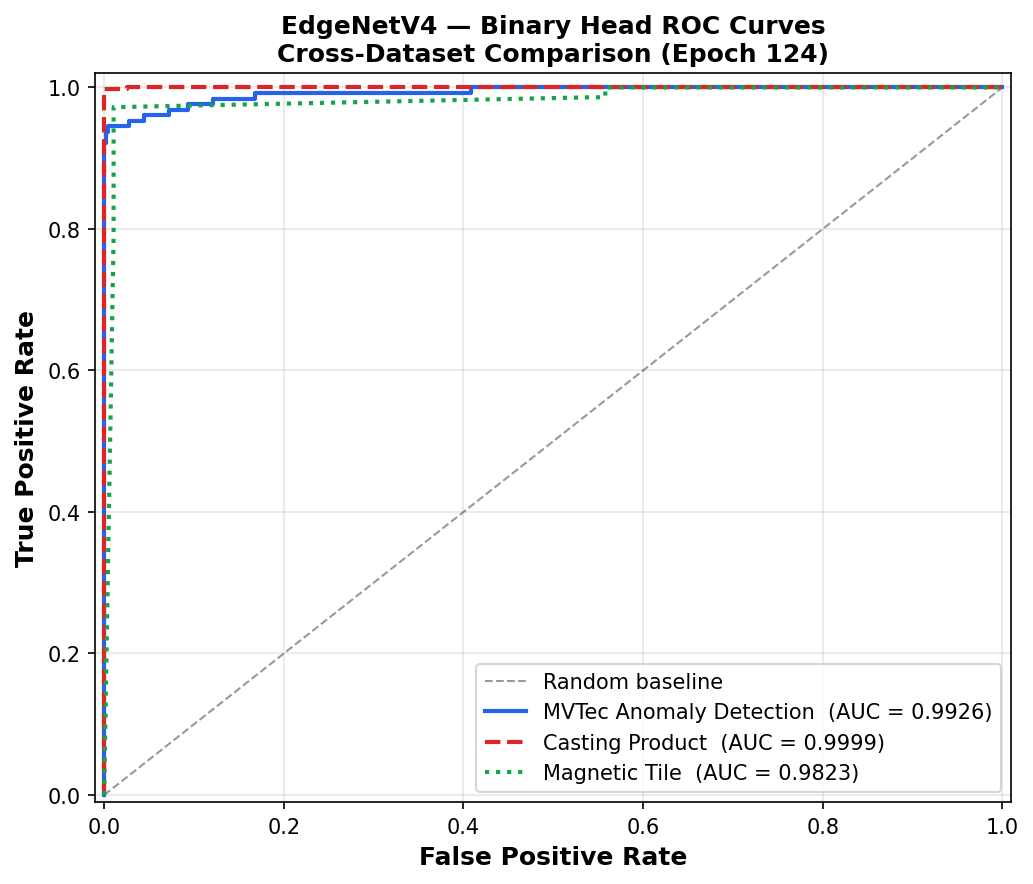

Saved → /home/sufi/training_results/figures/cross_dataset_eval/cross_dataset_roc.png
✅ CELL 13 COMPLETE


In [14]:
DS_STYLES = {
    'mvtec'   : ('#2563eb', '-',  'MVTec Anomaly Detection'),
    'casting' : ('#dc2626', '--', 'Casting Product'),
    'magnetic': ('#16a34a', ':',  'Magnetic Tile'),
}

fig, ax = plt.subplots(figsize=(7, 6), dpi=150, facecolor='white')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random baseline')

for ds_name, (color, ls, label) in DS_STYLES.items():
    r = all_results[ds_name]
    if len(np.unique(r['binary_true'])) < 2:
        continue
    fpr, tpr, _ = roc_curve(r['binary_true'], r['binary_scores'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, ls=ls,
            label=f'{label}  (AUC = {roc_auc:.4f})')

ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.02])
ax.set_xlabel('False Positive Rate', fontweight='bold', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontweight='bold', fontsize=12)
ax.set_title(
    'EdgeNetV4 — Binary Head ROC Curves\nCross-Dataset Comparison (Epoch 124)',
    fontweight='bold', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()

path = os.path.join(OUT_DIR, 'cross_dataset_roc.png')
plt.savefig(path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {path}')
print('✅ CELL 13 COMPLETE')

In [15]:
rows = []
for ds_name in ['mvtec', 'casting', 'magnetic']:
    r     = all_results[ds_name]
    mode  = dataset_split_mode[ds_name]
    bt    = r['binary_true']
    bp    = (r['binary_scores'] >= 0.5).astype(int)
    bs    = r['binary_scores']

    bf1   = f1_score(bt, bp, average='binary', zero_division=0)
    bmac  = f1_score(bt, bp, average='macro',  zero_division=0)
    try:  bauc = roc_auc_score(bt, bs)
    except: bauc = float('nan')

    mask = (bt == 1) & (r['defect_true'] >= 0)
    if mask.sum() >= 5:
        df1 = f1_score(r['defect_true'][mask].astype(int),
                       r['defect_preds'][mask].astype(int),
                       average='macro', labels=list(range(8)),
                       zero_division=0)
        typed_n = int(mask.sum())
    else:
        df1, typed_n = float('nan'), int(mask.sum())

    rows.append({
        'Dataset'              : ds_name.capitalize(),
        'Split Mode'           : mode,
        'Test Samples'         : len(bt),
        'Normal'               : int((bt==0).sum()),
        'Defective'            : int((bt==1).sum()),
        'Binary F1'            : round(bf1, 4),
        'Binary Macro F1'      : round(bmac, 4),
        'AUC-ROC'              : round(bauc, 4),
        'Defect-Type Samples'  : typed_n,
        'Defect-Type Macro F1' : round(df1, 4) if not np.isnan(df1) else 'N/A',
    })

summary_df = pd.DataFrame(rows).set_index('Dataset')

print('=' * 90)
print('CROSS-DATASET VALIDATION SUMMARY — EdgeNetV4 (Epoch 124, Checkpoint F1 = 0.9662)')
print('=' * 90)
print(summary_df.to_string())
print('=' * 90)

csv_path = os.path.join(OUT_DIR, 'cross_dataset_summary.csv')
summary_df.to_csv(csv_path)
print(f'\nSaved CSV → {csv_path}')
print('✅ CELL 14 COMPLETE')

CROSS-DATASET VALIDATION SUMMARY — EdgeNetV4 (Epoch 124, Checkpoint F1 = 0.9662)
         Split Mode  Test Samples  Normal  Defective  Binary F1  Binary Macro F1  AUC-ROC  Defect-Type Samples Defect-Type Macro F1
Dataset                                                                                                                            
Mvtec      csv_test           556     428        128     0.9551           0.9712   0.9926                   97               0.9429
Casting    csv_test           850     347        503     0.9990           0.9988   0.9999                    0                  N/A
Magnetic   csv_test           262     190         72     0.9722           0.9808   0.9823                   72               0.3339

Saved CSV → /home/sufi/training_results/figures/cross_dataset_eval/cross_dataset_summary.csv
✅ CELL 14 COMPLETE


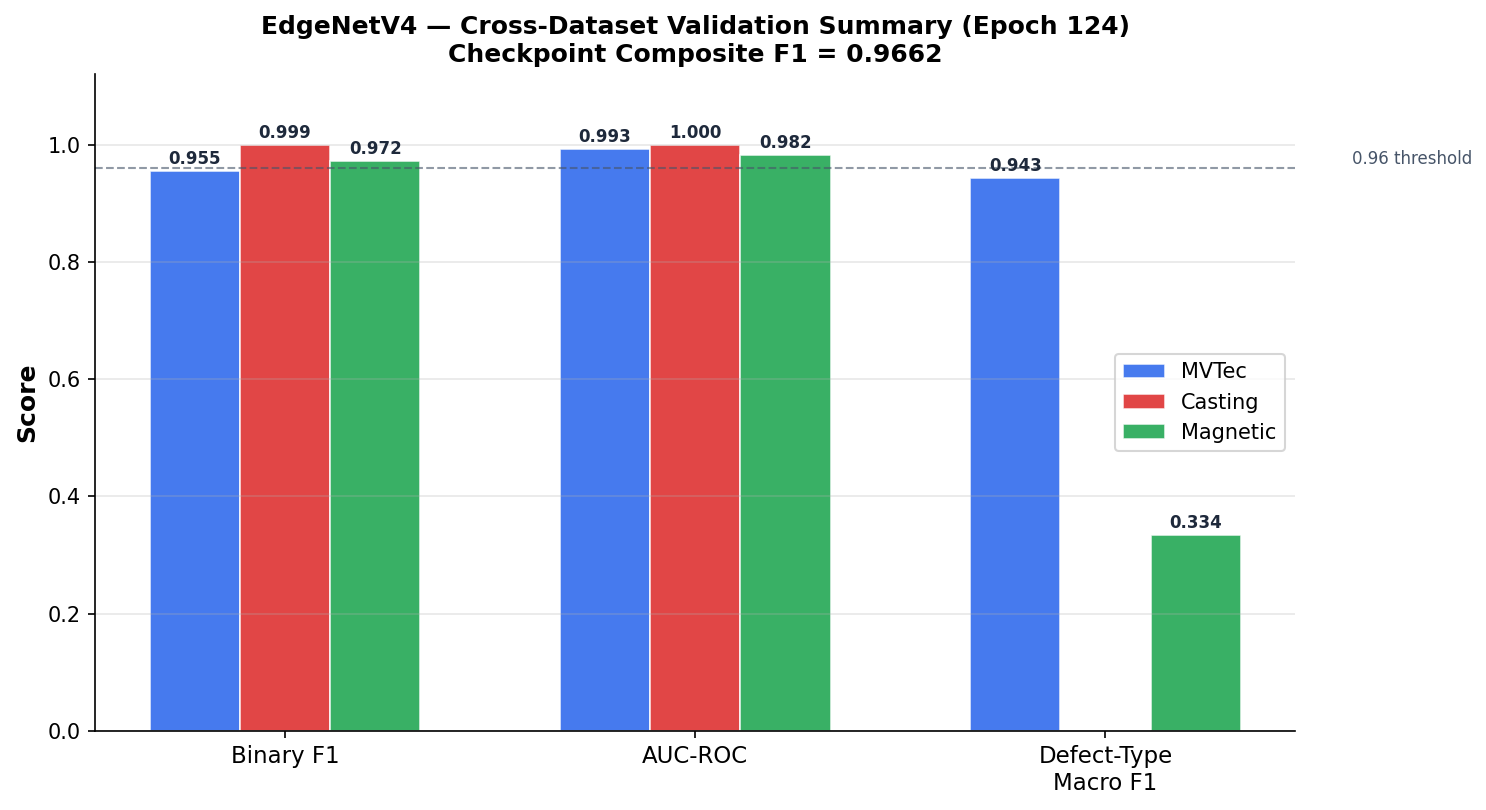

Saved → /home/sufi/training_results/figures/cross_dataset_eval/cross_dataset_bar.png
✅ CELL 15 COMPLETE


In [16]:
ds_labels = ['MVTec', 'Casting', 'Magnetic']
ds_keys   = ['mvtec', 'casting', 'magnetic']
COLORS    = ['#2563eb', '#dc2626', '#16a34a']

def get_metric(ds_name, metric):
    r  = all_results[ds_name]
    bt = r['binary_true']
    bp = (r['binary_scores'] >= 0.5).astype(int)
    bs = r['binary_scores']
    if metric == 'binary_f1':
        return f1_score(bt, bp, average='binary', zero_division=0)
    if metric == 'auc':
        try: return roc_auc_score(bt, bs)
        except: return float('nan')
    if metric == 'defect_f1':
        mask = (bt == 1) & (r['defect_true'] >= 0)
        if mask.sum() < 5: return 0.0
        return f1_score(r['defect_true'][mask].astype(int),
                        r['defect_preds'][mask].astype(int),
                        average='macro', labels=list(range(8)), zero_division=0)

metrics_to_plot = {
    'Binary F1'            : [get_metric(k, 'binary_f1')  for k in ds_keys],
    'AUC-ROC'              : [get_metric(k, 'auc')         for k in ds_keys],
    'Defect-Type\nMacro F1': [get_metric(k, 'defect_f1') for k in ds_keys],
}

n_metrics  = len(metrics_to_plot)
n_datasets = len(ds_labels)
x          = np.arange(n_metrics)
width      = 0.22

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150, facecolor='white')

for i, (ds_label, ds_key, color) in enumerate(zip(ds_labels, ds_keys, COLORS)):
    vals = [list(v)[i] for v in metrics_to_plot.values()]
    bars = ax.bar(x + (i - 1) * width, vals, width,
                  label=ds_label, color=color, alpha=0.85,
                  edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom',
                    fontsize=8, fontweight='bold', color='#1e293b')

ax.set_ylim(0, 1.12)
ax.set_xticks(x)
ax.set_xticklabels(list(metrics_to_plot.keys()), fontsize=11)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title(
    'EdgeNetV4 — Cross-Dataset Validation Summary (Epoch 124)\n'
    'Checkpoint Composite F1 = 0.9662',
    fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.96, color='#475569', ls='--', lw=1, alpha=0.6)
ax.text(n_metrics - 0.4, 0.961, '0.96 threshold', fontsize=8,
        color='#475569', va='bottom')
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)

plt.tight_layout()
path = os.path.join(OUT_DIR, 'cross_dataset_bar.png')
plt.savefig(path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {path}')
print('✅ CELL 15 COMPLETE')

MVTec — Binary F1 per Product Type
------------------------------------------------------------
   Product  n_total  n_normal  n_defect  Binary_F1  AUC_ROC
    bottle       22        17         5     1.0000   1.0000
      grid       38        33         5     1.0000   1.0000
    carpet       44        36         8     1.0000   1.0000
  hazelnut       49        47         2     1.0000   1.0000
   leather       36        26        10     1.0000   1.0000
      tile       44        29        15     1.0000   1.0000
 metal_nut       39        27        12     1.0000   1.0000
      wood       32        27         5     1.0000   1.0000
    zipper       40        27        13     1.0000   1.0000
     cable       46        34        12     0.9565   1.0000
      pill       24        17         7     0.9231   0.9748
   capsule       47        29        18     0.8750   0.9004
     screw       48        37        11     0.8421   0.9484
transistor       35        32         3     0.8000   0.9896
toot

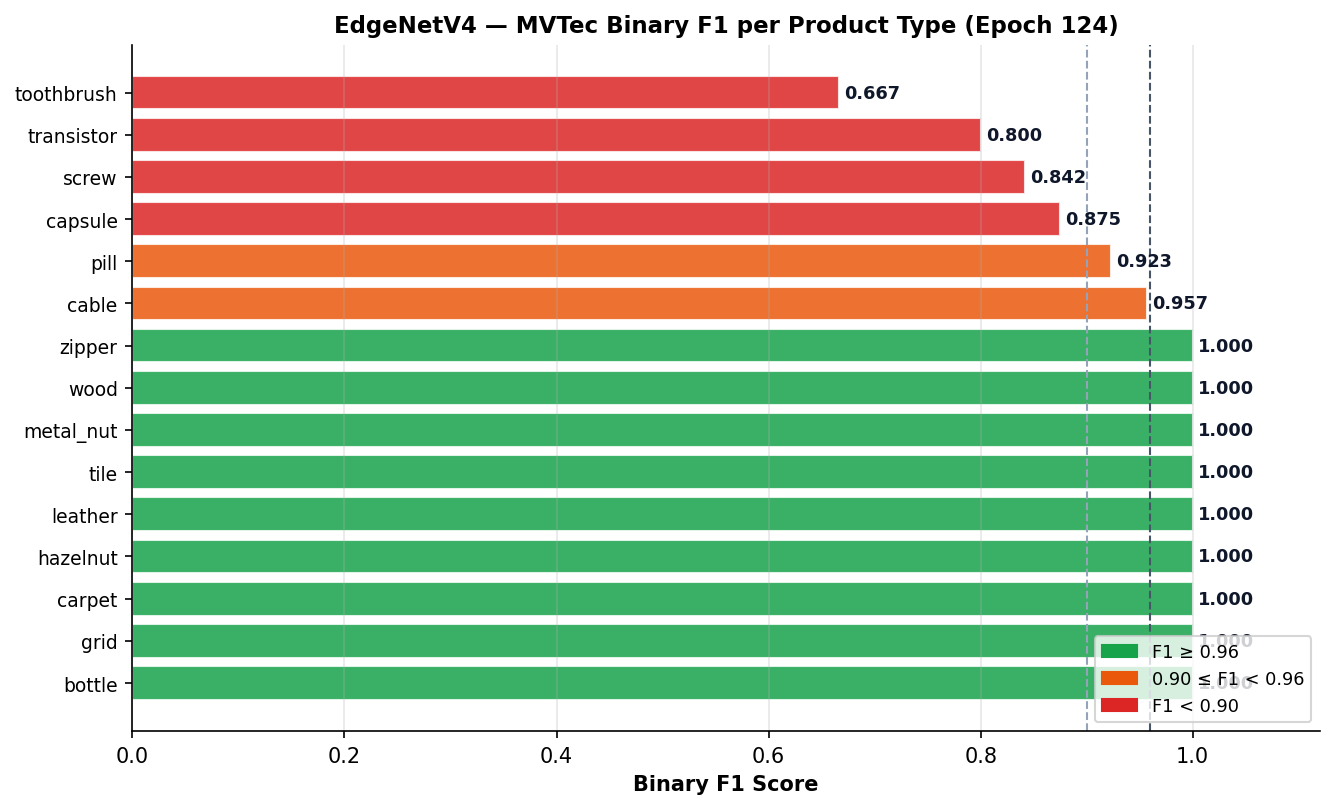

Saved → /home/sufi/training_results/figures/cross_dataset_eval/mvtec_per_product_f1.png
✅ CELL 16 COMPLETE


In [17]:
res    = all_results['mvtec']
df_ref = dataset_test_dfs['mvtec'].reset_index(drop=True)

assert len(res['binary_true']) == len(df_ref), \
    'Length mismatch: loader order vs CSV'

df_ref = df_ref.copy()
df_ref['_bin_pred']  = (res['binary_scores'] >= 0.5).astype(int)
df_ref['_bin_score'] = res['binary_scores']

product_rows = []
for prod, grp in df_ref.groupby('product_type'):
    y_t = grp['binary_label'].values
    y_p = grp['_bin_pred'].values
    y_s = grp['_bin_score'].values
    if len(np.unique(y_t)) < 2:
        bf1  = f1_score(y_t, y_p, average='binary', zero_division=0)
        bauc = float('nan')
    else:
        bf1  = f1_score(y_t, y_p, average='binary', zero_division=0)
        bauc = roc_auc_score(y_t, y_s)

    product_rows.append({
        'Product'  : prod,
        'n_total'  : len(grp),
        'n_normal' : int((y_t == 0).sum()),
        'n_defect' : int((y_t == 1).sum()),
        'Binary_F1': round(bf1, 4),
        'AUC_ROC'  : round(bauc, 4) if not np.isnan(bauc) else 'N/A',
    })

prod_df = pd.DataFrame(product_rows).sort_values('Binary_F1', ascending=False)

print('MVTec — Binary F1 per Product Type')
print('-' * 60)
print(prod_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150, facecolor='white')
products   = prod_df['Product'].tolist()
f1_vals    = prod_df['Binary_F1'].tolist()
bar_colors = [f1_color(v) for v in f1_vals]

bars = ax.barh(range(len(products)), f1_vals, color=bar_colors,
               alpha=0.85, edgecolor='white')
for i, (bar, val) in enumerate(zip(bars, f1_vals)):
    ax.text(val + 0.005, i, f'{val:.3f}', va='center',
            fontsize=8.5, color='#0f172a', fontweight='bold')

ax.set_yticks(range(len(products)))
ax.set_yticklabels(products, fontsize=9)
ax.set_xlabel('Binary F1 Score', fontweight='bold')
ax.set_xlim(0, 1.12)
ax.axvline(0.96, color='#475569', ls='--', lw=1)
ax.axvline(0.90, color='#94a3b8', ls='--', lw=1)
ax.set_title(
    'EdgeNetV4 — MVTec Binary F1 per Product Type (Epoch 124)',
    fontweight='bold', fontsize=11)

patches = [
    mpatches.Patch(color='#16a34a', label='F1 ≥ 0.96'),
    mpatches.Patch(color='#ea580c', label='0.90 ≤ F1 < 0.96'),
    mpatches.Patch(color='#dc2626', label='F1 < 0.90'),
]
ax.legend(handles=patches, fontsize=8.5, loc='lower right')
ax.grid(axis='x', alpha=0.3)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)

plt.tight_layout()
path = os.path.join(OUT_DIR, 'mvtec_per_product_f1.png')
plt.savefig(path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {path}')
print('✅ CELL 16 COMPLETE')

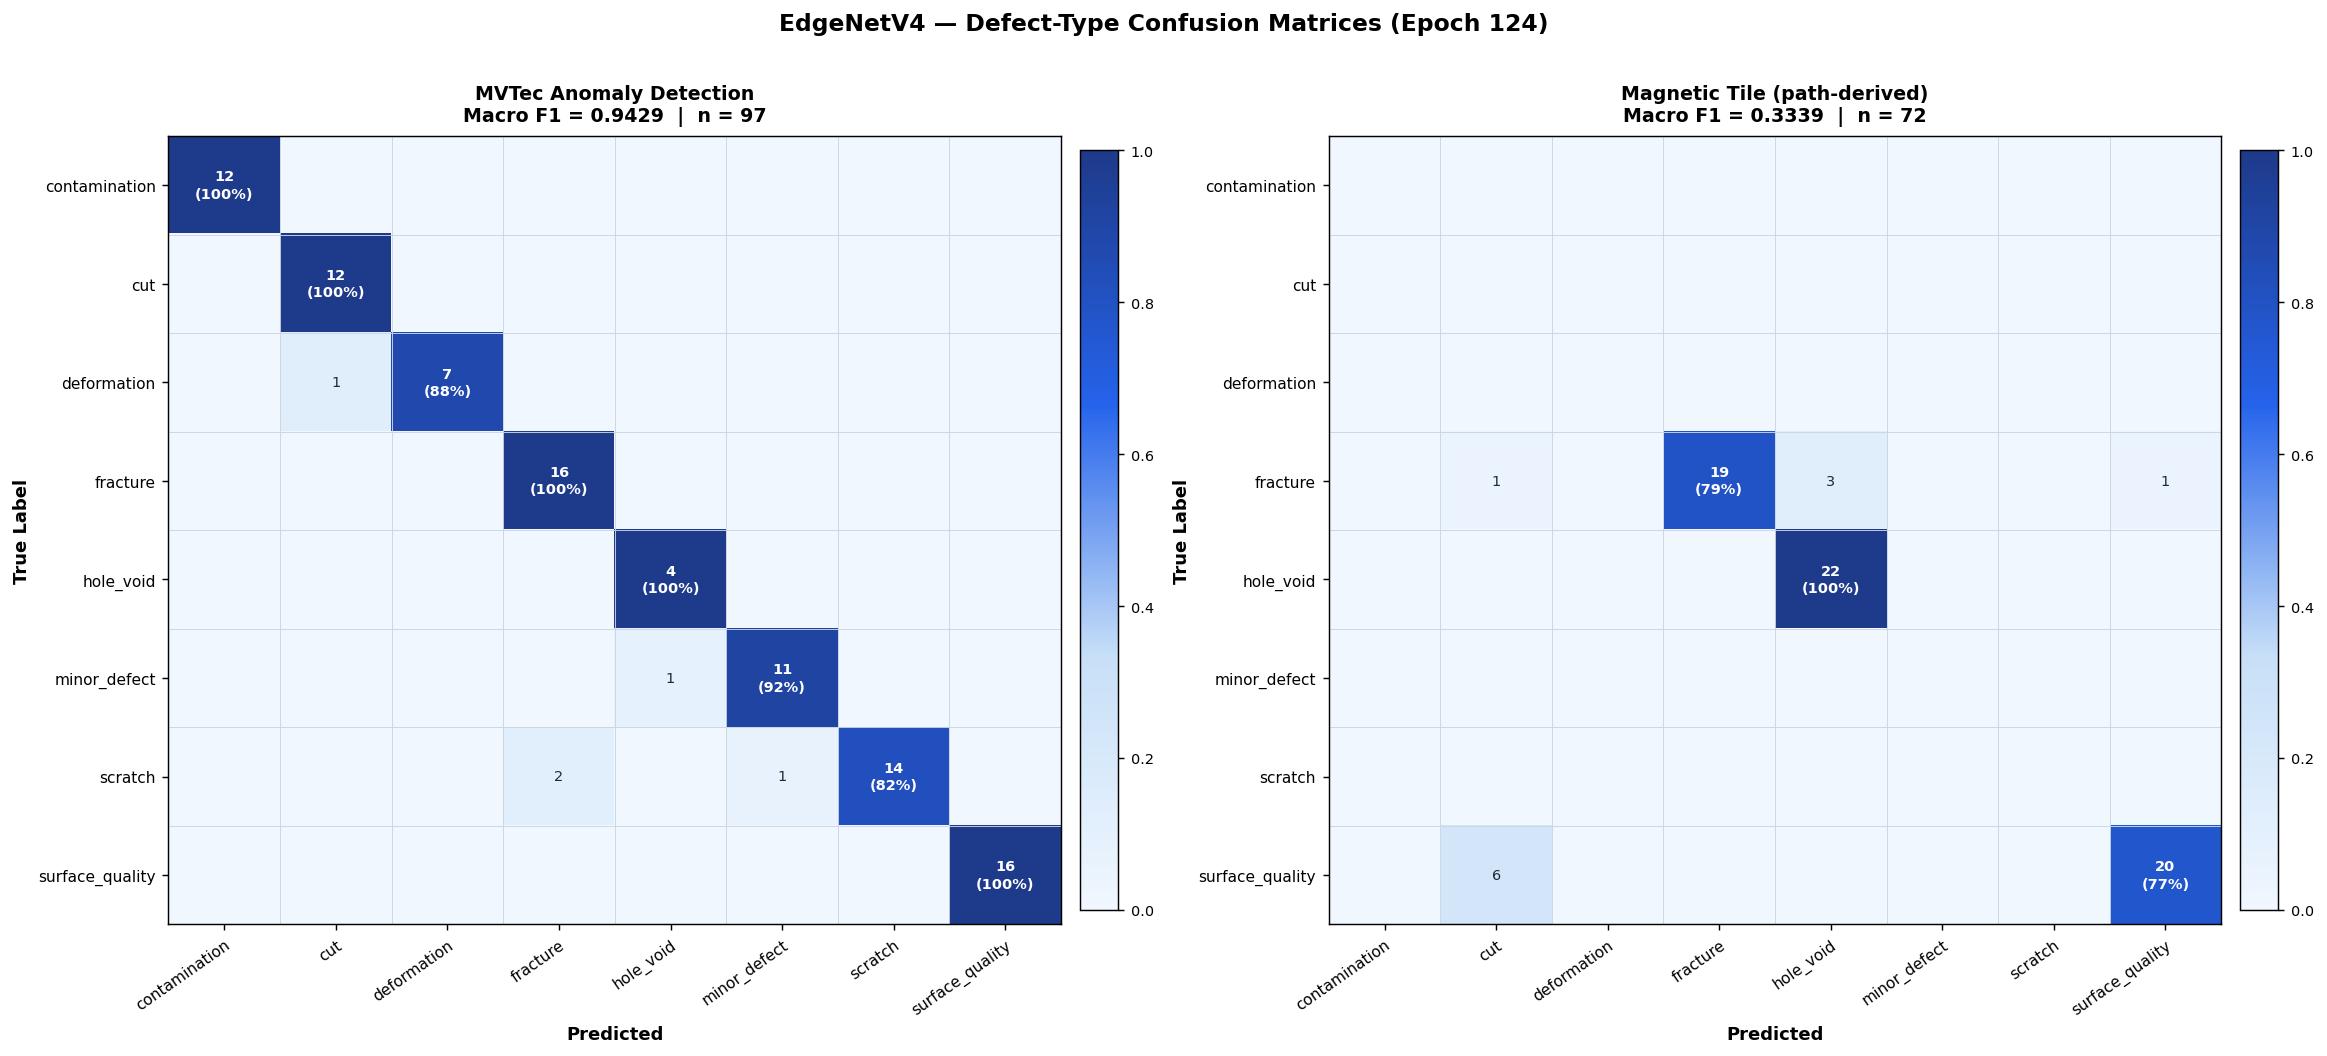

Saved → /home/sufi/training_results/figures/cross_dataset_eval/cross_dataset_cm_panel.png
✅ CELL 17 COMPLETE


In [18]:
def _cm_data(ds_name):
    r    = all_results[ds_name]
    mask = (r['binary_true'] == 1) & (r['defect_true'] >= 0)
    if mask.sum() == 0:
        return None, None, 0
    y_t = r['defect_true'][mask].astype(int)
    y_p = r['defect_preds'][mask].astype(int)
    return y_t, y_p, int(mask.sum())

panel_datasets = [
    ('mvtec',    'MVTec Anomaly Detection',      '#2563eb'),
    ('magnetic', 'Magnetic Tile (path-derived)', '#16a34a'),
]
panels = [(ds, ttl, col) for ds, ttl, col in panel_datasets
          if _cm_data(ds)[2] > 0]

if len(panels) == 0:
    print('No datasets with typed defect labels — skipping panel figure')
else:
    N_CLS  = 8
    labels = list(range(N_CLS))
    n_panels = len(panels)
    fig, axes = plt.subplots(1, n_panels,
                             figsize=(9 * n_panels, 8),
                             dpi=130, facecolor='white')
    if n_panels == 1:
        axes = [axes]

    for ax, (ds_name, ds_title, color) in zip(axes, panels):
        y_t, y_p, n = _cm_data(ds_name)
        cm_raw  = confusion_matrix(y_t, y_p, labels=labels)
        row_tot = cm_raw.sum(axis=1, keepdims=True).clip(min=1)
        cm_norm = cm_raw / row_tot
        macro_f1 = f1_score(y_t, y_p, average='macro',
                            labels=labels, zero_division=0)

        im = ax.imshow(cm_norm, cmap=CM_CMAP, vmin=0, vmax=1, aspect='auto')
        for k in range(N_CLS + 1):
            ax.axhline(k - 0.5, color='#cbd5e1', lw=0.5)
            ax.axvline(k - 0.5, color='#cbd5e1', lw=0.5)

        for i in range(N_CLS):
            for j in range(N_CLS):
                cnt = cm_raw[i, j]
                if cnt == 0: continue
                v  = cm_norm[i, j]
                fc = 'white' if v > 0.5 else '#1e293b'
                bold = 'bold' if i == j else 'normal'
                txt  = f'{cnt}\n({v:.0%})' if i == j else str(cnt)
                ax.text(j, i, txt, ha='center', va='center',
                        fontsize=8, fontweight=bold,
                        color=fc, linespacing=1.3)

        ax.set_xticks(range(N_CLS))
        ax.set_xticklabels(SEMANTIC_GROUPS, rotation=35,
                           ha='right', fontsize=8.5, rotation_mode='anchor')
        ax.set_yticks(range(N_CLS))
        ax.set_yticklabels(SEMANTIC_GROUPS, fontsize=8.5)
        ax.set_xlabel('Predicted', fontweight='bold', fontsize=10)
        ax.set_ylabel('True Label', fontweight='bold', fontsize=10)
        ax.set_title(
            f'{ds_title}\nMacro F1 = {macro_f1:.4f}  |  n = {n}',
            fontweight='bold', fontsize=10.5, pad=8)
        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02).ax.tick_params(labelsize=8)

    fig.suptitle(
        'EdgeNetV4 — Defect-Type Confusion Matrices (Epoch 124)',
        fontweight='bold', fontsize=13, y=1.01)
    plt.tight_layout()
    path = os.path.join(OUT_DIR, 'cross_dataset_cm_panel.png')
    plt.savefig(path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {path}')

print('✅ CELL 17 COMPLETE')

In [19]:
SEP = '═' * 75

print(SEP)
print('EdgeNetV4 — Cross-Dataset Validation Report')
print(f'Checkpoint : {V4_CKPT}')
print(f'Epoch      : {saved_epoch}    Saved composite F1 : {saved_score:.4f}')
print(SEP)

for ds_name in ['mvtec', 'casting', 'magnetic']:
    r     = all_results[ds_name]
    mode  = dataset_split_mode[ds_name]
    bt    = r['binary_true']
    bp    = (r['binary_scores'] >= 0.5).astype(int)
    bs    = r['binary_scores']

    bf1   = f1_score(bt, bp, average='binary', zero_division=0)
    bmac  = f1_score(bt, bp, average='macro',  zero_division=0)
    try:  bauc = roc_auc_score(bt, bs)
    except: bauc = float('nan')

    mask = (bt == 1) & (r['defect_true'] >= 0)
    if mask.sum() >= 5:
        df1 = f1_score(r['defect_true'][mask].astype(int),
                       r['defect_preds'][mask].astype(int),
                       average='macro', labels=list(range(8)),
                       zero_division=0)
        _, _, df1_per, support = precision_recall_fscore_support(
            r['defect_true'][mask].astype(int),
            r['defect_preds'][mask].astype(int),
            labels=list(range(8)), zero_division=0)
    else:
        df1, df1_per, support = float('nan'), [], []

    DSEP = '-' * 60
    print(f'\n▶ {ds_name.upper()} ANOMALY DETECTION  [{mode}]')
    print(DSEP)
    print(f'  Test samples     : {len(bt):,}'
          f'  (normal={int((bt==0).sum())}, defective={int((bt==1).sum())})')
    print(f'  Binary F1        : {bf1:.4f}')
    print(f'  Binary Macro F1  : {bmac:.4f}')
    print(f'  AUC-ROC          : {bauc:.4f}')
    if not np.isnan(df1):
        print(f'  Defect-type Macro F1 : {df1:.4f}  '
              f'(n={int(mask.sum())} typed defects)')
        print(f'  Per-class F1:')
        for cls, f1v, sup in zip(SEMANTIC_GROUPS, df1_per, support):
            tag = '✅' if f1v >= 0.96 else '🔶' if f1v >= 0.90 else '❌'
            print(f'    {tag} {cls:<20}  F1={f1v:.4f}  n={int(sup)}')
    else:
        print(f'  Defect-type F1   : N/A (fewer than 5 typed samples)')

print(f'\n{SEP}')
print('All figures saved to:', OUT_DIR)
print('  cross_dataset_roc.png         — ROC comparison (3 datasets)')
print('  cross_dataset_bar.png         — metric bar chart')
print('  cross_dataset_cm_panel.png    — confusion matrix panels')
print('  cross_dataset_summary.csv     — table for LaTeX import')
print('  mvtec_binary_roc.png          — MVTec ROC')
print('  mvtec_defect_cm.png           — MVTec defect confusion matrix')
print('  mvtec_per_product_f1.png      — MVTec per-product F1')
print('  casting_binary_roc.png        — Casting ROC')
print('  magnetic_binary_roc.png       — Magnetic ROC')
print('  magnetic_defect_cm.png        — Magnetic defect confusion matrix')
print(SEP)

═══════════════════════════════════════════════════════════════════════════
EdgeNetV4 — Cross-Dataset Validation Report
Checkpoint : /home/sufi/training_results/models/V4/EdgeNet_V4_best.pth
Epoch      : 124    Saved composite F1 : 0.9662
═══════════════════════════════════════════════════════════════════════════

▶ MVTEC ANOMALY DETECTION  [csv_test]
------------------------------------------------------------
  Test samples     : 556  (normal=428, defective=128)
  Binary F1        : 0.9551
  Binary Macro F1  : 0.9712
  AUC-ROC          : 0.9926
  Defect-type Macro F1 : 0.9429  (n=97 typed defects)
  Per-class F1:
    ✅ contamination         F1=1.0000  n=12
    ✅ cut                   F1=0.9600  n=12
    🔶 deformation           F1=0.9333  n=8
    🔶 fracture              F1=0.9412  n=16
    ❌ hole_void             F1=0.8889  n=4
    🔶 minor_defect          F1=0.9167  n=12
    🔶 scratch               F1=0.9032  n=17
    ✅ surface_quality       F1=1.0000  n=16

▶ CASTING ANOMALY DETECTIO